## Subgraphs in Langgraph

### Subgraph not sharing a state

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
subgraph_llm = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [4]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [5]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [6]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [7]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [8]:
parent_llm = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [9]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [11]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

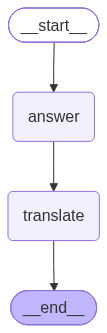

In [12]:
graph = parent_builder.compile()

graph

In [13]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is the branch of science that studies matter and energy at very small scales, like atoms and the particles inside them.\n\nIt explains things that classical physics cannot, such as:\n- particles behaving like both particles and waves\n- energy coming in small, fixed amounts called quanta\n- particles being in multiple possible states at once until measured\n- weird links between particles called entanglement\n\nIn short, quantum physics describes the rules of the microscopic world.',
 'answer_hin': 'क्वांटम भौतिकी विज्ञान की वह शाखा है जो पदार्थ और ऊर्जा का अध्ययन बहुत छोटे पैमानों पर करती है, जैसे परमाणु और उनके भीतर मौजूद कण।\n\nयह उन चीज़ों की व्याख्या करती है जिन्हें शास्त्रीय भौतिकी समझा नहीं पाती, जैसे:\n- कणों का एक साथ कण और तरंग दोनों की तरह व्यवहार करना\n- ऊर्जा का छोटे, निश्चित मात्राओं में आना, जिन्हें क्वांटा कहा जाता है\n- कणों का मापे जाने तक एक साथ कई संभावित अवस्थाओं में होना\n- कणों के बीच अजीब सं

### Interrupt the private-state subgraph

The subgraph below sleeps for 20 seconds before translating. The parent graph uses a checkpointer, so when you **interrupt this cell**, the parent does not lose work that already finished.

1. Run the next two cells to build the graphs.
2. Run the `invoke` cell. When it prints `Subgraph started...`, hit **Interrupt** (stop button).
3. Run the inspection cell. You should still see `question` and `answer_eng`. `answer_hin` will be missing because the subgraph never finished.
4. The subgraph's private keys (`input_text`, `translated_text`) never appear on the parent.

In [24]:
import time
from langgraph.checkpoint.memory import InMemorySaver

def translate_text_slow(state: SubState):
    print("Subgraph started. Waiting 20 seconds — interrupt the cell now...")
    time.sleep(20)
    print("Subgraph finished waiting. Translating...")

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content
    return {"translated_text": translated_text}

slow_subgraph_builder = StateGraph(SubState)
slow_subgraph_builder.add_node("translate_text", translate_text_slow)
slow_subgraph_builder.add_edge(START, "translate_text")
slow_subgraph_builder.add_edge("translate_text", END)
slow_subgraph = slow_subgraph_builder.compile()

def translate_answer_isolated(state: ParentState):
    result = slow_subgraph.invoke({"input_text": state["answer_eng"]})
    return {"answer_hin": result["translated_text"]}

isolated_checkpointer = InMemorySaver()
isolated_parent_builder = StateGraph(ParentState)
isolated_parent_builder.add_node("answer", generate_answer)
isolated_parent_builder.add_node("translate", translate_answer_isolated)
isolated_parent_builder.add_edge(START, "answer")
isolated_parent_builder.add_edge("answer", "translate")
isolated_parent_builder.add_edge("translate", END)

isolated_graph = isolated_parent_builder.compile(checkpointer=isolated_checkpointer)
isolated_config = {"configurable": {"thread_id": "interrupt-demo"}}

In [25]:
# Interrupt this cell while it is sleeping in the subgraph.
isolated_graph.invoke({"question": "What is quantum physics"}, config=isolated_config)

Subgraph started. Waiting 20 seconds — interrupt the cell now...


KeyboardInterrupt: 

In [26]:
snapshot = isolated_graph.get_state(isolated_config)

print("Parent state after interrupt:")
print(snapshot.values)
print("\nNext node that still needs to run:", snapshot.next)
print("Parent keys only:", list(snapshot.values.keys()))

Parent state after interrupt:
{'question': 'What is quantum physics', 'answer_eng': 'Quantum physics is the branch of science that studies matter and energy at very small scales, like atoms and subatomic particles.\n\nIt explains things that classical physics cannot, such as:\n- particles behaving like both particles and waves\n- electrons existing in uncertain states until measured\n- energy being absorbed or emitted in tiny discrete amounts, called quanta\n\nQuantum physics is the foundation of many technologies, including:\n- computers and semiconductors\n- lasers\n- MRI machines\n- solar cells\n\nIn short, it describes how the microscopic world works.'}

Next node that still needs to run: ('translate',)
Parent keys only: ['question', 'answer_eng']


In [ ]:
# Optional: resume the parent from the last checkpoint. The English answer is reused;
# only the subgraph translation runs again.
isolated_graph.invoke(None, config=isolated_config)

### SubGraph Sharing a state

In [14]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

In [15]:
load_dotenv()

True

In [16]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [17]:
parent_llm = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
subgraph_llm = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)

In [18]:
def translate_text(state: ParentState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [19]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [20]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [21]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

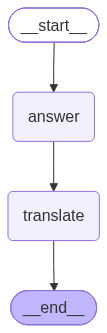

In [22]:
graph = parent_builder.compile()

graph

In [23]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is the branch of science that studies matter and energy at very small scales, such as atoms and subatomic particles.\n\nIt explains behaviors that don’t match everyday intuition, like:\n- particles acting like waves\n- energy being exchanged in tiny packets called quanta\n- objects existing in multiple possible states until measured\n- particles being linked in unusual ways, called entanglement\n\nQuantum physics is the foundation of many modern technologies, including:\n- semiconductors and computer chips\n- lasers\n- MRI scanners\n- solar cells\n\nIn short, quantum physics describes how nature works at the smallest scales.',
 'answer_hin': 'क्वांटम भौतिकी विज्ञान की वह शाखा है जो पदार्थ और ऊर्जा का अध्ययन बहुत छोटे पैमानों पर करती है, जैसे परमाणु और उपपरमाण्विक कण।\n\nयह उन व्यवहारों को समझाती है जो रोज़मर्रा की समझ से मेल नहीं खाते, जैसे:\n- कणों का तरंगों की तरह व्यवहार करना\n- ऊर्जा का क्वांटा कहलाने वाले छोटे

### Interrupt the shared-state subgraph

This time the subgraph **is** a parent node and uses the same `ParentState`. There is no private boundary.

1. Run the setup cell.
2. Run the `invoke` cell.
3. **If you wait 20 seconds:** it translates and returns the full result (`question`, `answer_eng`, `answer_hin`).
4. **If you hit Interrupt during the wait:** the whole `invoke()` fails with `KeyboardInterrupt`. Then run the inspection cell, and optionally the resume cell to finish the translation.

In [35]:
import time
from langgraph.checkpoint.memory import InMemorySaver

def translate_text_shared_slow(state: ParentState):
    print("Shared subgraph started. Waiting 20 seconds — interrupt now, or wait to let it finish.")
    time.sleep(20)
    print("Subgraph finished waiting. Translating...")

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["answer_eng"]}
""".strip()

    translated_text = subgraph_llm.invoke(prompt).content
    return {"answer_hin": translated_text}

shared_slow_builder = StateGraph(ParentState)
shared_slow_builder.add_node("translate_text", translate_text_shared_slow)
shared_slow_builder.add_edge(START, "translate_text")
shared_slow_builder.add_edge("translate_text", END)
shared_slow_subgraph = shared_slow_builder.compile()

shared_checkpointer = InMemorySaver()
shared_parent_builder = StateGraph(ParentState)
shared_parent_builder.add_node("answer", generate_answer)
shared_parent_builder.add_node("translate", shared_slow_subgraph)
shared_parent_builder.add_edge(START, "answer")
shared_parent_builder.add_edge("answer", "translate")
shared_parent_builder.add_edge("translate", END)

shared_graph = shared_parent_builder.compile(checkpointer=shared_checkpointer)
shared_config = {"configurable": {"thread_id": "shared-interrupt-demo"}}

In [36]:
# Wait 20s to finish, or interrupt during the sleep.
# If you already interrupted an older run, re-run the setup cell first.
shared_graph.invoke({"question": "What is quantum physics"}, config=shared_config)

Shared subgraph started. Waiting 20 seconds — interrupt now, or wait to let it finish.


KeyboardInterrupt: 

In [37]:
snapshot = shared_graph.get_state(shared_config)

print("Checkpointed parent state:")
print(snapshot.values)
print("\nNext node:", snapshot.next)
print("Parent keys:", list(snapshot.values.keys()))

if snapshot.next:
    print("\nGraph is incomplete — you interrupted during translate. Run the resume cell to finish.")
else:
    print("\nGraph finished. Hindi answer is in answer_hin.")

Checkpointed parent state:
{'question': 'What is quantum physics', 'answer_eng': 'Quantum physics is the branch of science that studies how matter and energy behave at very small scales, like atoms, electrons, and photons.\n\nIt explains phenomena that classical physics can’t, such as:\n- particles acting like both waves and particles\n- energy coming in small packets called quanta\n- uncertainty in measuring some properties exactly\n- particles becoming linked in a special way called entanglement\n\nIn simple terms, quantum physics describes the rules of the tiny world. It is the foundation for technologies like semiconductors, lasers, and quantum computers.'}

Next node: ('translate',)
Parent keys: ['question', 'answer_eng']

Graph is incomplete — you interrupted during translate. Run the resume cell to finish.


In [38]:
# Resume from the last checkpoint if you interrupted.
# It waits 20s again, then translates and completes.
shared_graph.invoke(None, config=shared_config)

Shared subgraph started. Waiting 20 seconds — interrupt now, or wait to let it finish.
Subgraph finished waiting. Translating...


{'question': 'What is quantum physics',
 'answer_eng': 'Quantum physics is the branch of science that studies how matter and energy behave at very small scales, like atoms, electrons, and photons.\n\nIt explains phenomena that classical physics can’t, such as:\n- particles acting like both waves and particles\n- energy coming in small packets called quanta\n- uncertainty in measuring some properties exactly\n- particles becoming linked in a special way called entanglement\n\nIn simple terms, quantum physics describes the rules of the tiny world. It is the foundation for technologies like semiconductors, lasers, and quantum computers.',
 'answer_hin': 'क्वांटम भौतिकी विज्ञान की वह शाखा है जो बहुत छोटे पैमाने, जैसे परमाणुओं, इलेक्ट्रॉनों और फोटॉनों, पर पदार्थ और ऊर्जा के व्यवहार का अध्ययन करती है।\n\nयह उन घटनाओं को समझाती है जिन्हें शास्त्रीय भौतिकी नहीं समझा सकती, जैसे:\n- कणों का तरंग और कण, दोनों की तरह व्यवहार करना\n- ऊर्जा का क्वांटा कहलाने वाले छोटे-छोटे पैकेटों में आना\n- कुछ गुण